In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [69]:
df= pd.read_csv('../datasets/mymoviedb.csv', lineterminator='\n')
df

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...
...,...,...,...,...,...,...,...,...,...
9822,1973-10-15,Badlands,A dramatization of the Starkweather-Fugate kil...,13.357,896,7.6,en,"Drama, Crime",https://image.tmdb.org/t/p/original/z81rBzHNgi...
9823,2020-10-01,Violent Delights,A female vampire falls in love with a man she ...,13.356,8,3.5,es,Horror,https://image.tmdb.org/t/p/original/4b6HY7rud6...
9824,2016-05-06,The Offering,When young and successful reporter Jamie finds...,13.355,94,5.0,en,"Mystery, Thriller, Horror",https://image.tmdb.org/t/p/original/h4uMM1wOhz...
9825,2021-03-31,The United States vs. Billie Holiday,Billie Holiday spent much of her career being ...,13.354,152,6.7,en,"Music, Drama, History",https://image.tmdb.org/t/p/original/vEzkxuE2sJ...


In [70]:
df.shape

(9827, 9)

In [71]:
df.columns= df.columns.str.lower().str.replace(' ', '_')

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   release_date       9827 non-null   object 
 1   title              9827 non-null   object 
 2   overview           9827 non-null   object 
 3   popularity         9827 non-null   float64
 4   vote_count         9827 non-null   int64  
 5   vote_average       9827 non-null   float64
 6   original_language  9827 non-null   object 
 7   genre              9827 non-null   object 
 8   poster_url         9827 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.1+ KB


In [73]:
#checking null
df.isna().sum()

release_date         0
title                0
overview             0
popularity           0
vote_count           0
vote_average         0
original_language    0
genre                0
poster_url           0
dtype: int64

In [74]:
#checking duplcated values
df.duplicated().value_counts()

False    9827
Name: count, dtype: int64

In [75]:
# typecasting data to proper types

df['release_date']= pd.to_datetime(df['release_date'], format='%Y-%m-%d')

df['original_language']= df['original_language'].astype('category')

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   release_date       9827 non-null   datetime64[ns]
 1   title              9827 non-null   object        
 2   overview           9827 non-null   object        
 3   popularity         9827 non-null   float64       
 4   vote_count         9827 non-null   int64         
 5   vote_average       9827 non-null   float64       
 6   original_language  9827 non-null   category      
 7   genre              9827 non-null   object        
 8   poster_url         9827 non-null   object        
dtypes: category(1), datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 625.3+ KB


In [77]:
# splitting genre with multiple values into different rows
genres= df['genre'].str.split(', ', expand= True).stack().reset_index(level=1, drop= True).rename('genre')

df= df.rename(columns= {'genre': 'orig_genre'})

new_df= pd.merge(df, genres, left_index= True, right_index= True)

In [78]:
#converting genre into categorical value
new_df['genre']= new_df['genre'].astype('category')

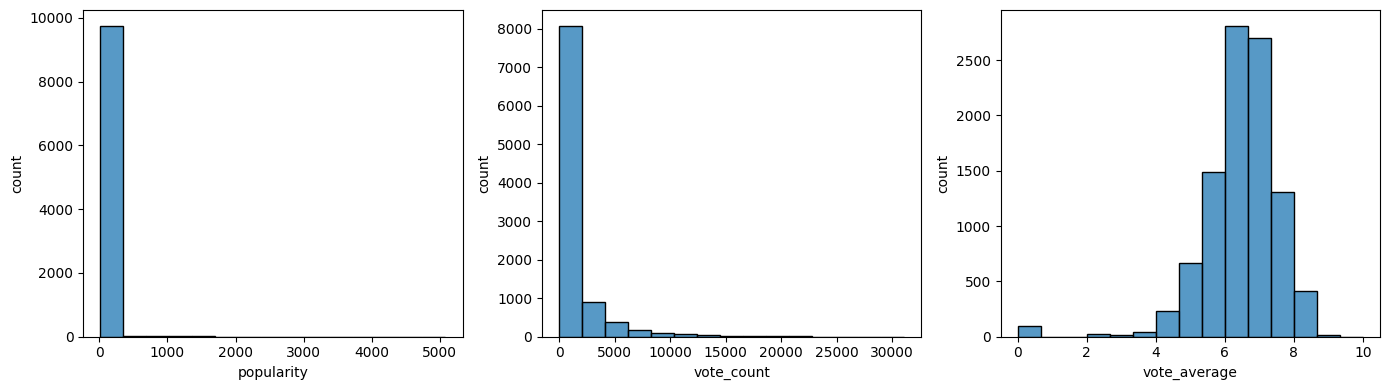

In [79]:
#plotting distributions for numeric columns
df.columns
num_columns= ['popularity', 'vote_count', 'vote_average']


fig, ax= plt.subplots(1, 3, figsize= (14, 4))
for i, col in enumerate(num_columns):
    sns.histplot(x= df[col], bins= 15, ax= ax[i],)
    ax[i].set_xlabel(col)
    ax[i].set_ylabel('count')

fig.tight_layout()

## A LOT OF OUTLIERS

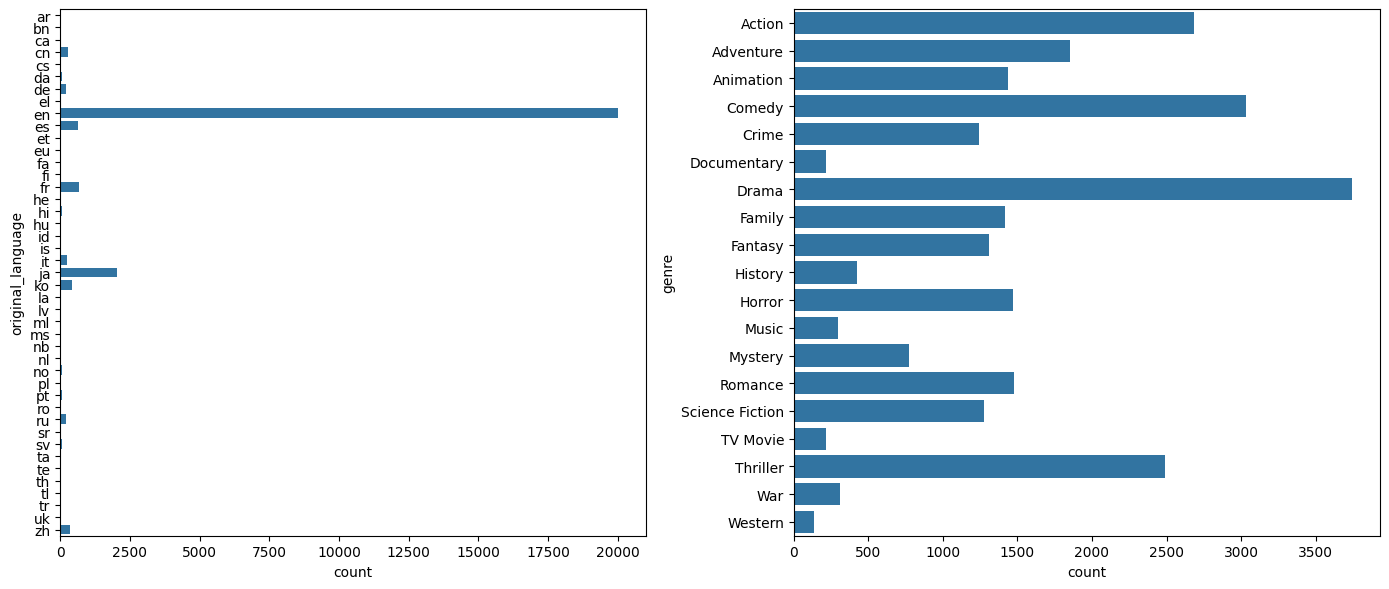

In [80]:
#looking at the distribution
cat_columns= ['original_language', 'genre']

fig, ax= plt.subplots(1, 2, figsize= (14, 6))
for i, col in enumerate(cat_columns):
    sns.countplot(y= new_df[col], ax= ax[i])
    ax[i].set_ylabel(col)
    ax[i].set_xlabel('count')

fig.tight_layout()

## genre is fine, need to change original_language

In [81]:
#looking at popularity by year
df['release_year']= df['release_date'].dt.year

year_groups= df.groupby('release_year')
median_popularity= year_groups.median(numeric_only= True)['popularity'].tail(10)
median_popularity

release_year
2015    22.4065
2016    21.1615
2017    22.2185
2018    20.4895
2019    22.8515
2020    24.1720
2021    50.7265
2022    33.0735
2023    38.4870
2024    27.9870
Name: popularity, dtype: float64

Text(0.5, 1.0, 'Popularity trends over last 10 years')

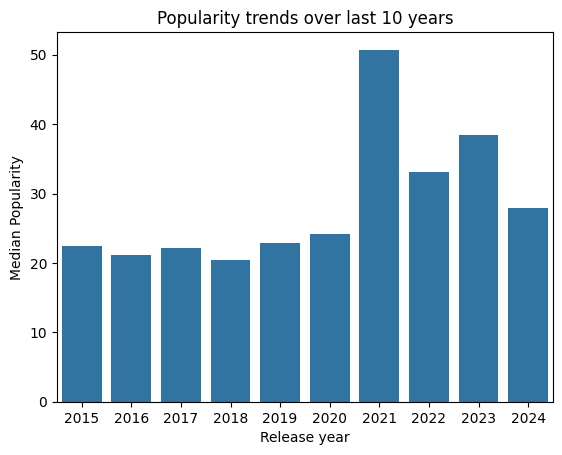

In [82]:
#plotting median movie ratings by year
sns.barplot(x= median_popularity.index, y= median_popularity)
plt.xlabel('Release year')
plt.ylabel('Median Popularity')
plt.title('Popularity trends over last 10 years')

# Cleaning the data 

In [83]:
#fixing numerical data
df['popularity_scaled']= np.log1p(df['popularity'])

df['popularity_scaled'].quantile([0.1, 0.25, 0.5, 0.75, 0.90, 0.95, 0.99, 1])

cap= df['popularity_scaled'].quantile(0.99)
df.loc[df['popularity_scaled'] > cap , 'popularity_scaled']= cap  

<Axes: xlabel='popularity_scaled', ylabel='Count'>

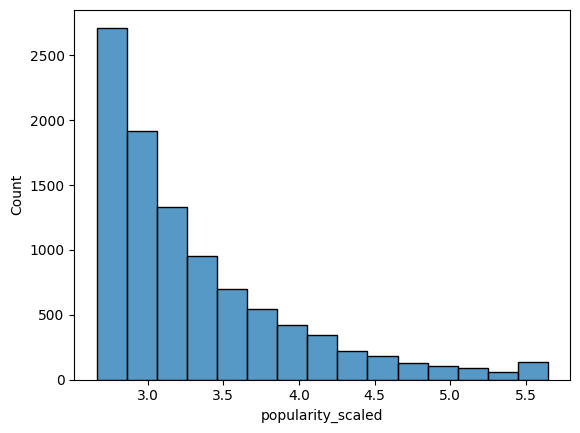

In [84]:
sns.histplot(x= df['popularity_scaled'], bins= 15)

In [85]:
df['vote_count_scaled']= np.log1p(df['vote_count'])
df['vote_count_scaled'].quantile([0.1, 0.25, 0.5, 0.75, 0.90, 0.95, 0.99, 1])

vote_count_cap= df['vote_count_scaled'].quantile(0.99)

df.loc[df['vote_count_scaled'] > vote_count_cap , 'vote_count_scaled']= int(vote_count_cap)  

<Axes: xlabel='vote_count_scaled', ylabel='Count'>

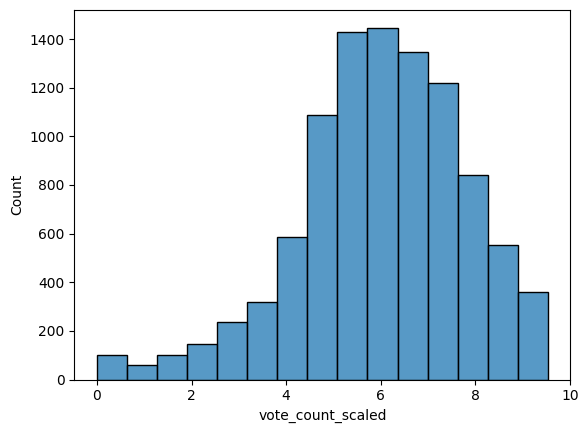

In [86]:
sns.histplot(x= df['vote_count_scaled'], bins= 15)

In [87]:
#fixing categorical comumn- 'original language'
language_counts= df['original_language'].value_counts()
lower_cap = language_counts.quantile(0.85) 

df['original_language']= df['original_language'].cat.add_categories('other')
other_languages = list(language_counts[language_counts < lower_cap].index)


df.loc[df['original_language'].isin(other_languages), 'original_language']= 'other'

df['original_language']= df['original_language'].cat.remove_unused_categories()

<Axes: xlabel='count', ylabel='original_language'>

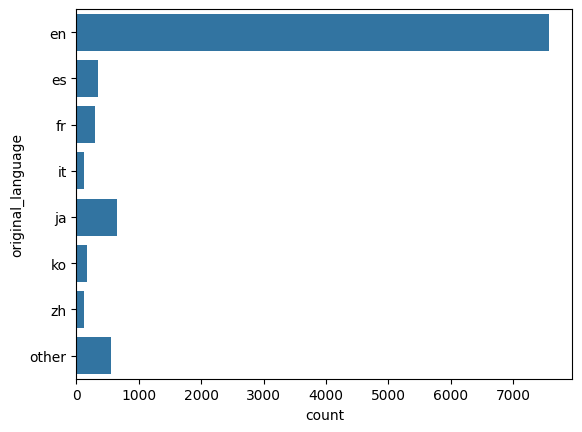

In [88]:
sns.countplot(y= df['original_language'])

In [89]:
#exporting cleaned data
df.to_csv('cleaned_mymovies_db.csv', lineterminator='\n', encoding='utf-8')